[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/06_power_mde_n.ipynb)

# Power, MDE and Sample Size  
  
Every experiment design revolves around four quantities that are tightly coupled:

| Quantity | Symbol | Typical default |
|---|---|---|
| Significance level (Type I error) | α | 0.05 |
| Type II error rate | β | 0.20 |
| Statistical power | 1 − β | 0.80 |
| Minimum Detectable Effect | MDE | depends on data |
| Sample size per group | n | depends on data |

Fix any three — the fourth is determined.  
**mcab** answers all four via Monte Carlo simulation rather than closed-form formulas.  
The Monte Carlo approach works on your real data distribution without normality assumptions, naturally handles any statistical test (t-test, bootstrap, permutation, etc.), and correctly accounts for skew, heavy tails, and other real-world properties of your metric.

This guide covers:
1. **Power for a single effect** — how often the test detects a given effect at the current sample size  
2. **Power curve** — how power varies across a range of effects  
3. **Finding the MDE** — the smallest effect the experiment can reliably detect  
4. **Sample size planning** — how many observations are needed to reach target power for a fixed effect


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from mcab import RandomData, AaDataIid, DesignerIid
from mcab.core import mean_ci_normal

# ── Reproducible synthetic data ────────────────────────────────────────────
# Replace with your own data: target = AaDataIid(your_series)
rd = RandomData(seed=42)
data = rd.normal_data(size=10_000, mean=100, std=30)

target = AaDataIid(data)
designer = DesignerIid(target, alpha=0.05, beta=0.20, seed=42)

# ── Statistical test ────────────────────────────────────────────────────────
# Swap in any callable (test, control) -> p-value:
# bootstrap, Mann-Whitney, permutation, etc.
pval_func = lambda t, c: stats.ttest_ind(t, c).pvalue

print(f"Dataset size : {len(data):,}")
print(f"Mean         : {data.mean():.2f}")
print(f"Std          : {data.std():.2f}")
print(f"α            : {designer.alpha}")
print(f"Target power : {1 - designer.beta:.0%}")


Dataset size : 10,000
Mean         : 99.69
Std          : 30.19
α            : 0.05
Target power : 80%


## Power for a Single Effect

**Statistical power** is the probability that the test correctly rejects H₀ when the effect truly exists:

$$\text{Power} = P(\text{reject } H_0 \mid H_1 \text{ is true}) = 1 - \beta$$

In a Monte Carlo simulation, power is estimated empirically:

1. Repeat `n_sims` times:
   - Randomly split data into test and control groups
   - **Inject** a synthetic effect into the test group (e.g. multiply by `1 + effect`)
   - Run the statistical test → record whether p < α
2. **Power ≈ fraction of simulations where the test rejected H₀**

`designer.calculate_some_power()` does exactly this and returns a binary array of length `n_sims`.


In [2]:
EFFECT = 0.02   # 2 % relative uplift
N_SIMS = 2_000  # more sims → narrower CI

rejections = designer.calculate_some_power(
    effect=EFFECT,
    pval_func=pval_func,
    n_sims=N_SIMS,
    verbose=False,
)

power, ci_low, ci_high = mean_ci_normal(rejections, alpha=designer.alpha)
target_power = 1 - designer.beta

print(f"Effect size      : {EFFECT:.1%}")
print(f"Power estimate   : {power:.3f}")
print(f"95 % CI          : [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Target power     : {target_power:.2f}")
print()
if ci_low > target_power:
    print("✅  Design achieves target power with confidence.")
elif ci_high < target_power:
    print("❌  Design falls SHORT of target power.")
else:
    print("⚠️   CI straddles the target — run more simulations or adjust n.")


Effect size      : 2.0%
Power estimate   : 0.896
95 % CI          : [0.883, 0.910]
Target power     : 0.80

✅  Design achieves target power with confidence.


### Interpreting the power estimate

- The **point estimate** is the fraction of simulations that rejected H₀.
- The **95 % CI** reflects Monte Carlo uncertainty (more sims → narrower interval).
- Rule of thumb for CI width:

| Target CI half-width | Recommended `n_sims` |
|---|---|
| ±5 pp | 500 |
| ±2 pp | 3 000 |
| ±1 pp | 10 000 |

If the CI straddles your target power (e.g. [0.77, 0.83] vs target 0.80), you have two options:
- **Increase `n_sims`** to shrink the interval and get a definitive answer.
- **Build a power curve** (next section) to understand the shape and locate the "knee" precisely.


## Power Curve

A **power curve** sweeps over a range of effect sizes and plots power at each point.  
It gives a much richer picture than a single-effect estimate:

- Where does power cross the target threshold? → that is the MDE.
- How fast does power grow? → sensitivity of the experiment.
- Does the curve saturate below 1.0? → possible test calibration issue.

The typical shape is **sigmoid (S-shaped)**:
- Small effects → power ≈ α (near-random guessing)
- Medium effects → rapid rise through the target zone
- Large effects → saturation near 1.0


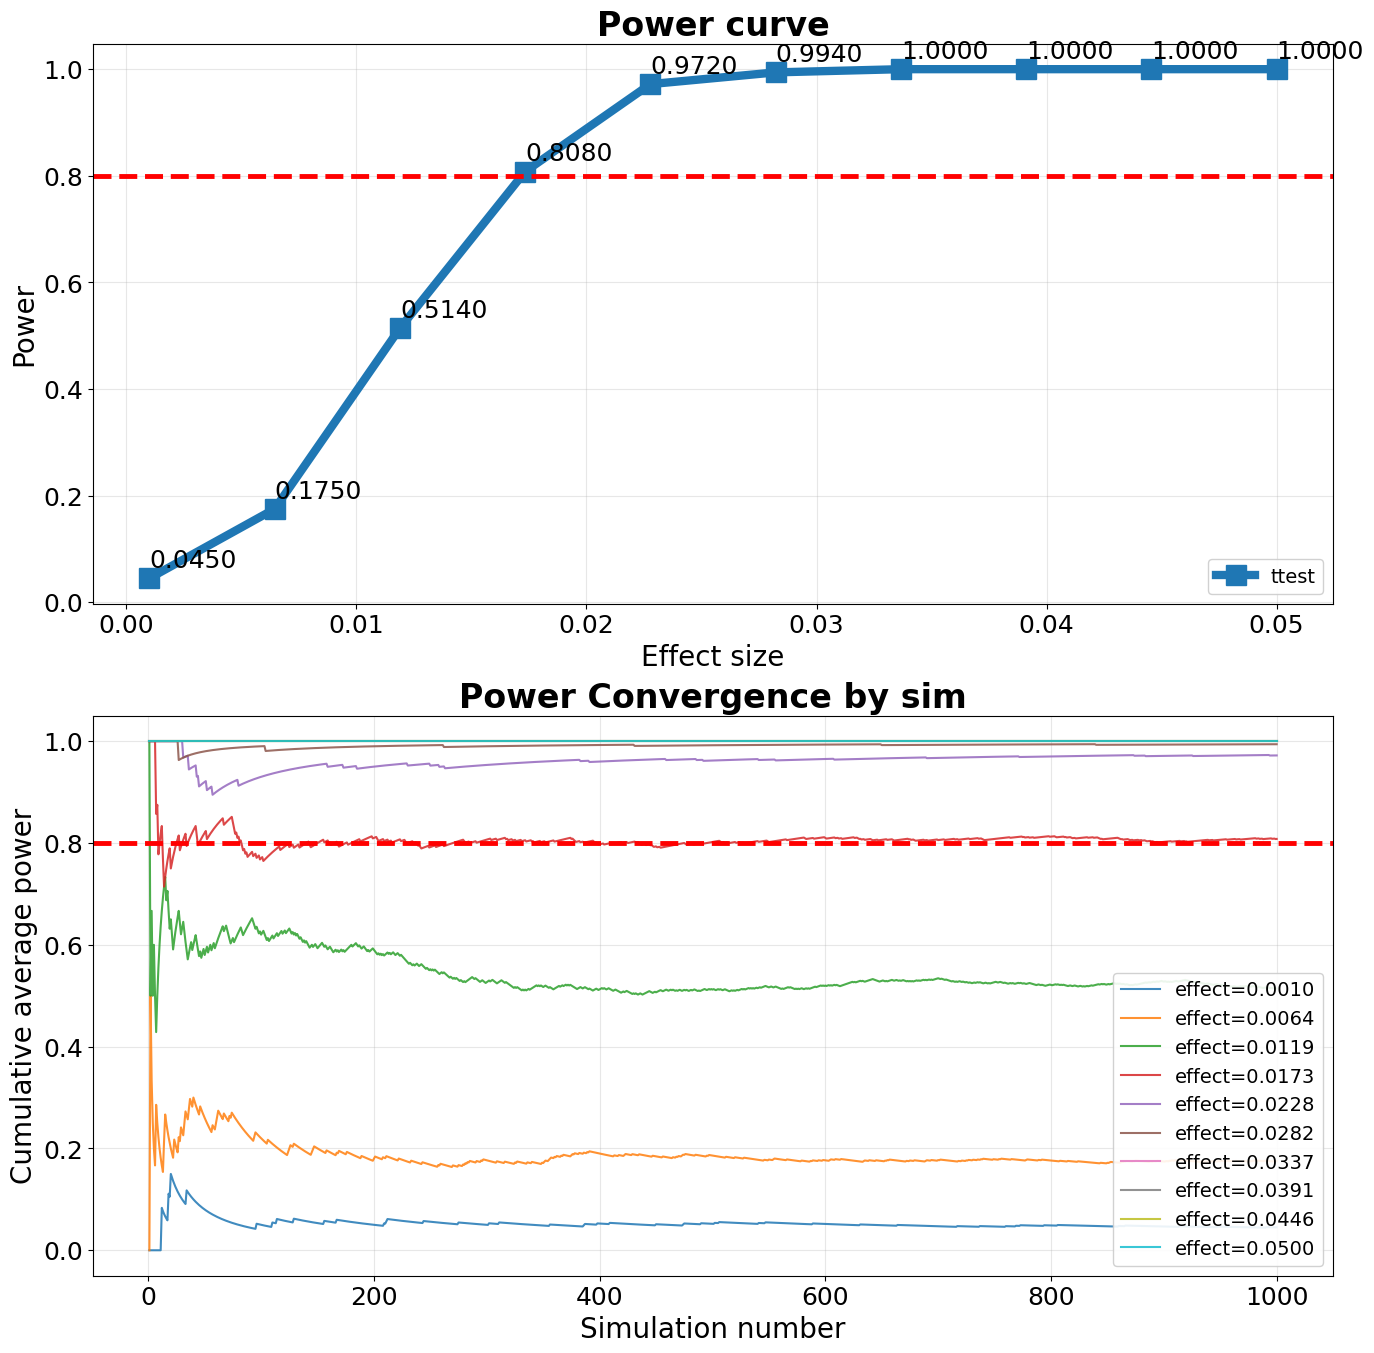

In [3]:
EFFECTS_RANGE = np.linspace(0.001, 0.05, 10) # 0.1 % – 5 % relative uplift
N_SIMS_CURVE  = 1_000                        # per point; increase for smoother curve

power_curve_result = designer.calculate_power_curve(
    effects_list=EFFECTS_RANGE,
    pval_funcs=[('ttest', pval_func)],
    n_sims=N_SIMS_CURVE,
    verbose=False,
    plot=True,          # built-in plot with the 1−β reference line
    annotate_curve=True,
)

effects_arr, powers_arr = power_curve_result[0]

### Reading the power curve

| Feature | What to look for |
|---|---|
| **Knee / crossing point** | Where the curve crosses `1 − β` — this is the empirical MDE. |
| **Slope around the knee** | Steep slope → power is sensitive to the exact effect size; flat slope → robust. |
| **Saturation** | Should reach ~1.0 for large effects; if it plateaus below that, the test may be miscalibrated. |
| **Noise** | Individual points wiggle due to MC randomness. Use more `n_sims` or smooth the curve for publication. |

The power curve is the single most useful diagnostic before running an experiment.  
The next section shows how `find_mde` automates locating the crossing point — and why you should always validate its output against the curve.


## Finding the MDE with `find_mde`

The **Minimum Detectable Effect (MDE)** is the smallest true effect for which the experiment achieves the target power:

$$\text{MDE} = \min \{ \delta : \text{Power}(\delta) \geq 1 - \beta \}$$

### How `find_mde` works internally

`find_mde` implements **binary search** over effect sizes:
```
low = 0,  high = some_large_effect
while |high - low| > tolerance:
mid = (low + high) / 2
power(mid) = fraction of n_sims simulations that reject H₀
if power(mid) >= target_power:
high = mid          # MDE is at most mid
else:
low  = mid          # MDE is at least mid
return mid
```
  

Binary search assumes power is **monotonically increasing** in effect size — which is true for the true power function but **not guaranteed for an individual noisy MC estimate**.  
If a noisy spike or valley fools the binary search, it can converge to a wrong point.

> **Best practice:** always validate `find_mde` output by plotting the power curve in the neighbourhood of the reported MDE.


✓ Target power reached for 12 iterations.
✓ MDE: 0.0173; Power: 0.8030; Target: 0.80; Iterations: 12


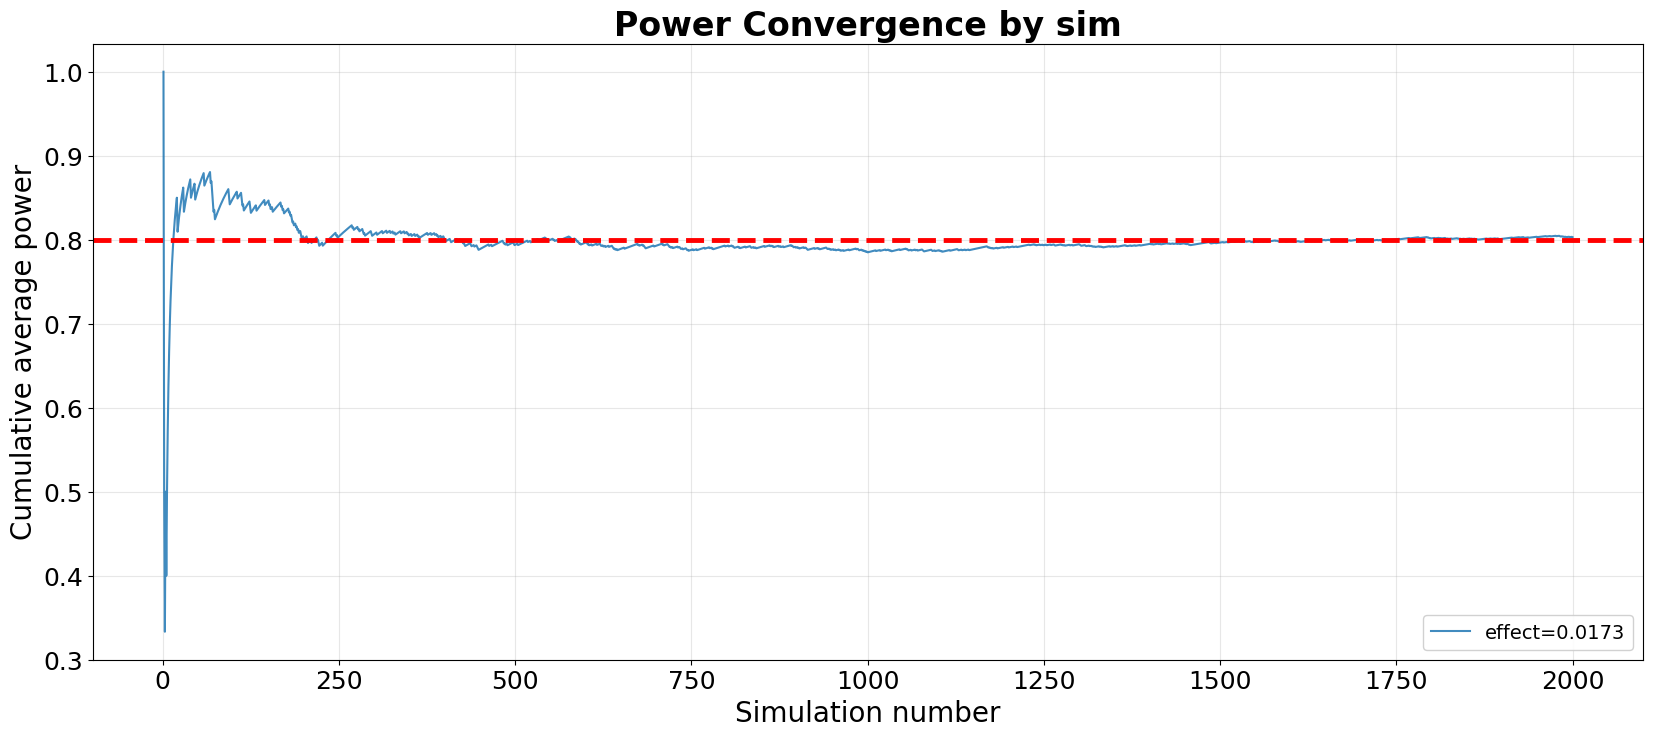


Reported MDE      : 0.0173  (1.73% relative effect)
Power at MDE      : 0.803
Target power      : 0.800


In [4]:
mde_result = designer.find_mde(
    pval_func=pval_func,
    target_power=0.80,
    n_sims=2_000,        # sims per evaluation inside binary search
    verbose=True,
)

mde_value = mde_result['mde']
achieved_power = mde_result['mde_power']

print(f"\nReported MDE      : {mde_value:.4f}  ({mde_value:.2%} relative effect)")
print(f"Power at MDE      : {achieved_power:.3f}")
print(f"Target power      : 0.800")

## ⚠️ Why `find_mde` Must Be Validated on the Surrounding Power Curve

`find_mde` returns a **single point estimate** obtained via binary search on noisy Monte Carlo evaluations.  
This creates two failure modes:

### Failure mode A — Spurious spike (MDE underestimated)

```
true power curve:      ...  0.74  0.76  0.78  0.80  0.82  ...
MC estimate:           ...  0.74  0.76  0.81* 0.80  0.82  ...
↑
Noise spike — binary search stops here early
→ reported MDE is too small
```
  
### Failure mode B — Spurious dip (MDE overestimated)
  
```
true power curve:      ...  0.78  0.80  0.82  0.84  ...
MC estimate:           ...  0.78  0.77* 0.82  0.84  ...
↑
Noise dip — binary search skips past the true MDE
→ reported MDE is too large
```
  
### How to guard against this

After calling `find_mde`, compute a fine power curve around the reported value and visually confirm:
- Power **below** MDE is clearly < target
- Power **above** MDE is clearly ≥ target
- The crossing is smooth, not a noisy artefact


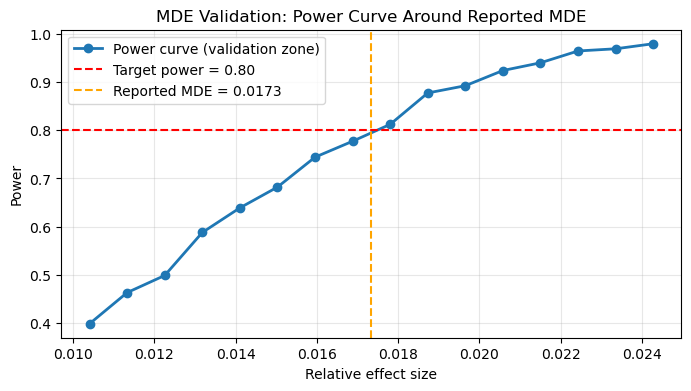

In [5]:
# ── Validate MDE by computing power manually at surrounding effect sizes ──
MARGIN = 0.40   # ±40 % around the reported MDE

effects_lo = mde_value * (1 - MARGIN)
effects_hi = mde_value * (1 + MARGIN)
validation_effects = np.linspace(effects_lo, effects_hi, 16)

# Compute power point-by-point — avoids any dependency on return structure
val_powers = []
for eff in validation_effects:
    rej = designer.calculate_some_power(
        effect=eff,
        pval_func=pval_func,
        n_sims=2_000,
        verbose=False,
    )
    val_powers.append(rej.mean())

val_powers = np.array(val_powers)

# ── Plot with MDE overlay ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(validation_effects, val_powers, marker='o', linewidth=2,
        label='Power curve (validation zone)')
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5,
           label='Target power = 0.80')
ax.axvline(mde_value, color='orange', linestyle='--', linewidth=1.5,
           label=f'Reported MDE = {mde_value:.4f}')

ax.set_xlabel('Relative effect size')
ax.set_ylabel('Power')
ax.set_title('MDE Validation: Power Curve Around Reported MDE')
ax.legend()
ax.grid(True, alpha=0.3)


## Sample Size Planning

Often the question is inverted:  
> *"We expect an effect of X. How many users do we need to achieve 80 % power?"*

`mcab` does not have a dedicated `find_n` method, but the answer is straightforward:  
fix the effect of interest, vary `control_size` across candidate sample sizes, and plot power vs. n.

**Why this approach is robust:**
- `control_size` controls how many observations are drawn per group in each simulation.
- The simulation resamples from your real data distribution, so the power estimate accounts for your actual metric's variance, skew, and other properties — not a textbook normal approximation.
- The "required n" is then simply the point where the curve crosses `1 − β`.


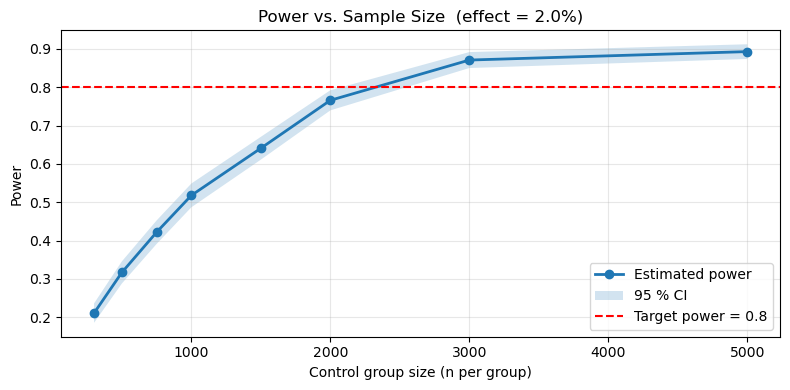


✅  Minimum control group size reaching 80% power: n = 3,000
    Achieved power at n=3,000: 0.871
    Total experiment size (50/50 split): ~6,000


In [6]:
EFFECT_TO_DETECT = 0.02      # the effect we care about
TARGET_POWER     = 0.80
N_SIMS_PER_SIZE  = 1_000

# Candidate sample sizes (control group; total ≈ 2× for 50/50 split)
sample_sizes = [300, 500, 750, 1_000, 1_500, 2_000, 3_000, 5_000]

powers_by_n      = []
ci_low_by_n      = []
ci_high_by_n     = []

for n in sample_sizes:
    rej = designer.calculate_some_power(
        effect=EFFECT_TO_DETECT,
        pval_func=pval_func,
        control_size=n,       # observations in control group per simulation
        n_sims=N_SIMS_PER_SIZE,
        verbose=False,
    )
    p, lo, hi = mean_ci_normal(rej, alpha=designer.alpha)
    powers_by_n.append(p)
    ci_low_by_n.append(lo)
    ci_high_by_n.append(hi)

powers_by_n = np.array(powers_by_n)
ci_low_by_n = np.array(ci_low_by_n)
ci_high_by_n = np.array(ci_high_by_n)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sample_sizes, powers_by_n, marker='o', linewidth=2, label='Estimated power')
ax.fill_between(sample_sizes, ci_low_by_n, ci_high_by_n, alpha=0.2, label='95 % CI')
ax.axhline(TARGET_POWER, color='red', linestyle='--', linewidth=1.5,
           label=f'Target power = {TARGET_POWER}')

ax.set_xlabel('Control group size (n per group)')
ax.set_ylabel('Power')
ax.set_title(f'Power vs. Sample Size  (effect = {EFFECT_TO_DETECT:.1%})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Find minimum sufficient n ──────────────────────────────────────────────
sufficient = [(n, p) for n, p in zip(sample_sizes, powers_by_n) if p >= TARGET_POWER]
if sufficient:
    min_n, min_power = sufficient[0]
    print(f"\n✅  Minimum control group size reaching {TARGET_POWER:.0%} power: n = {min_n:,}")
    print(f"    Achieved power at n={min_n:,}: {min_power:.3f}")
    print(f"    Total experiment size (50/50 split): ~{min_n * 2:,}")
else:
    print(f"\n❌  None of the tested sizes reached {TARGET_POWER:.0%} power.")
    print(    "    Try larger values in `sample_sizes` or a bigger effect.")


## Summary

This guide covered the full pre-experiment planning workflow in mcab:

| Question | mcab method | Key parameter |
|---|---|---|
| What power do I have for effect X? | `calculate_some_power(effect=X)` | `control_size` |
| How does power vary across effects? | `calculate_power_curve(effects_list=...)` | `n_sims` per point |
| What is my MDE? | `find_mde(target_power=0.8)` | `n_sims` inside search |
| What n do I need for effect X? | Loop over `calculate_some_power(control_size=n)` | `effect` |

### Recommended workflow

1. Build the power curve over a wide effect range ↓
2. Run find_mde to locate the crossing point automatically ↓
3. Validate find_mde by zooming into the surrounding curve ↓
4. If n is flexible: sweep sample sizes and find the minimum sufficient n  
  
### Tips for reliable estimates
  
- **`n_sims ≥ 1 000`** for a rough curve; **`n_sims ≥ 2 000`** near the MDE.
- **Re-run `find_mde` a few times** with different seeds to check stability.
- **Wide CI at the MDE crossing** → either increase `n_sims` or accept a range of plausible MDEs.
- Variance reduction (CUPED / CUPAC) shifts the power curve left — see Guide 8 for details.
